<class 'pandas.core.frame.DataFrame'>
Index: 92917 entries, 0 to 93024
Columns: 145 entries, player_id to fantasy_points_ppr
dtypes: float64(17), int32(115), object(13)
memory usage: 62.7+ MB
None


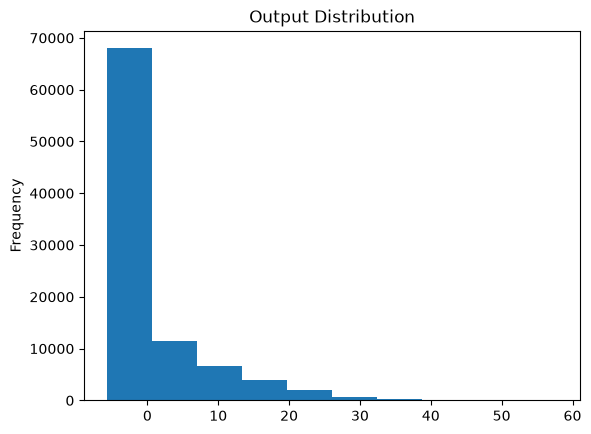

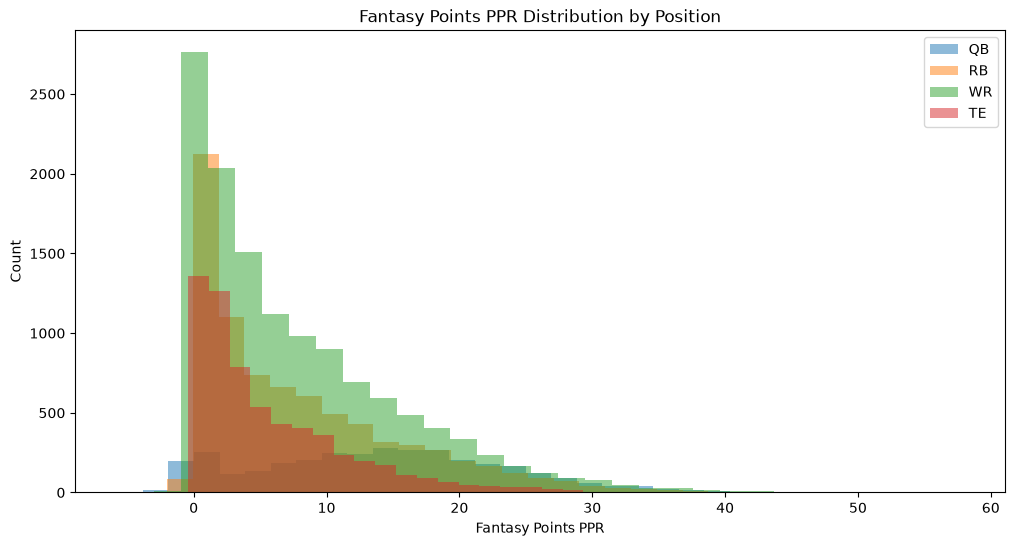

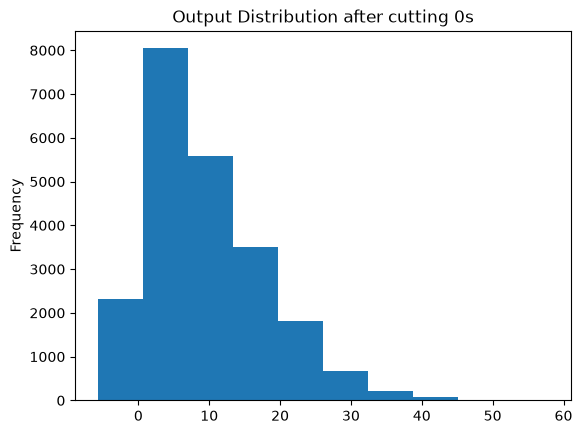

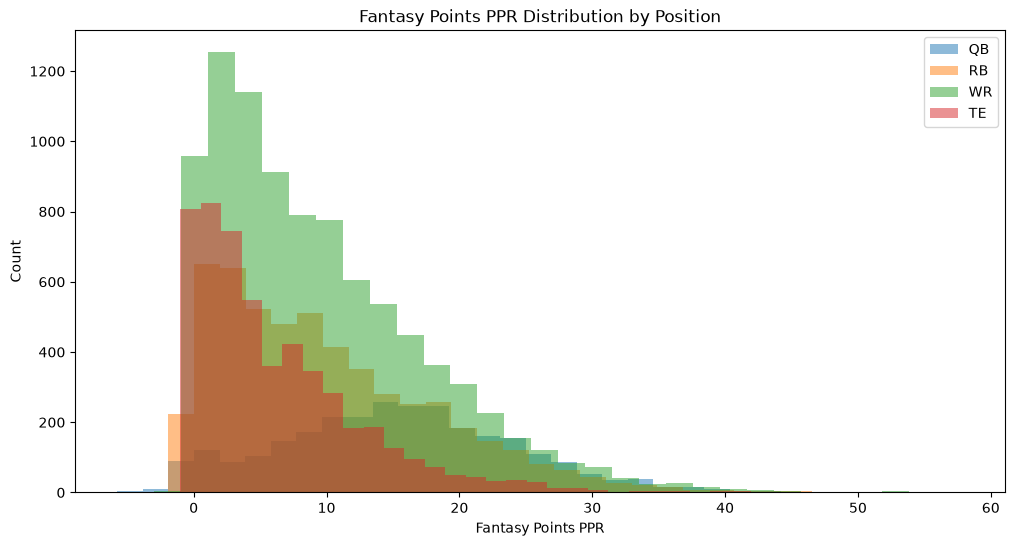

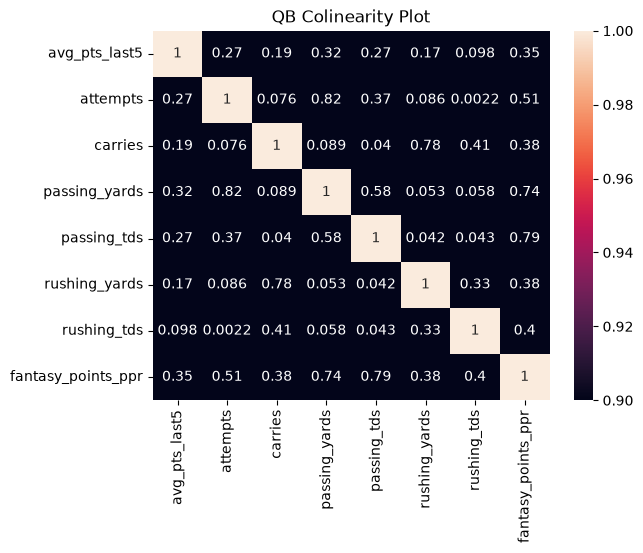

c:\python\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:381: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


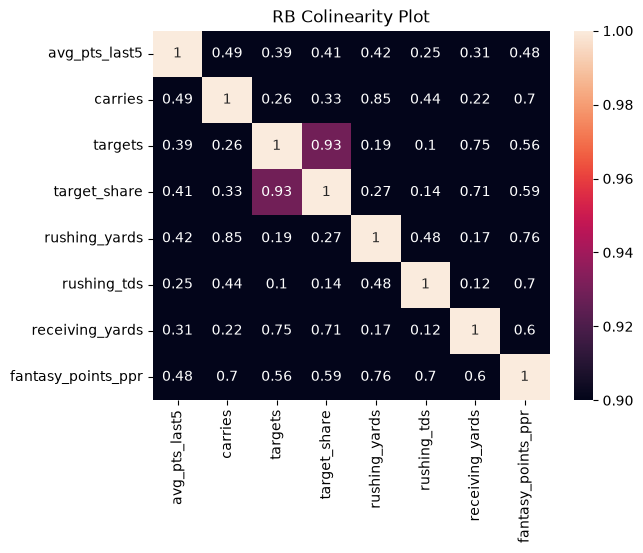

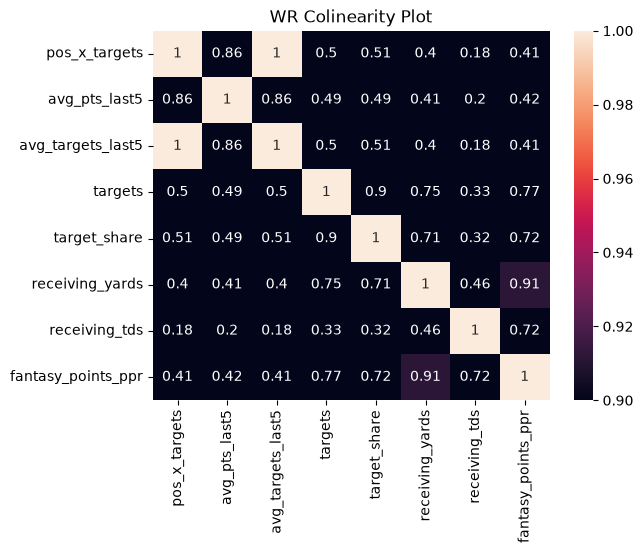

c:\python\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:381: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


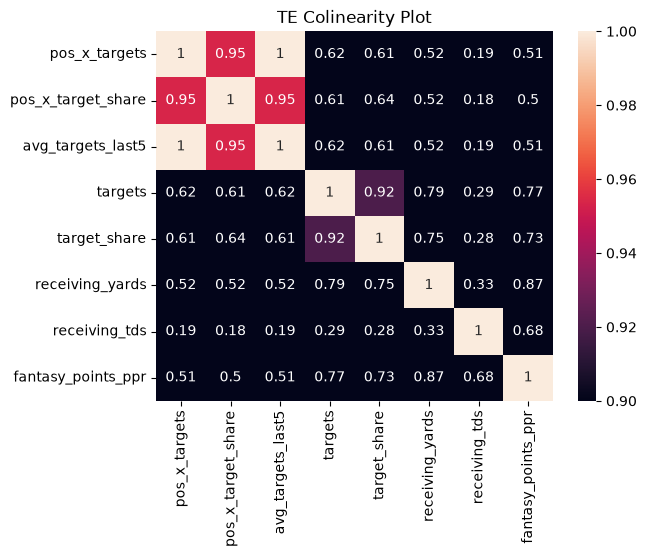

c:\python\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:381: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


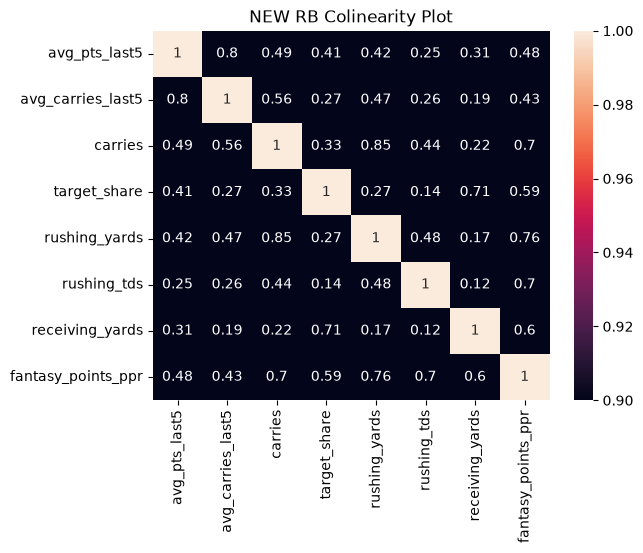

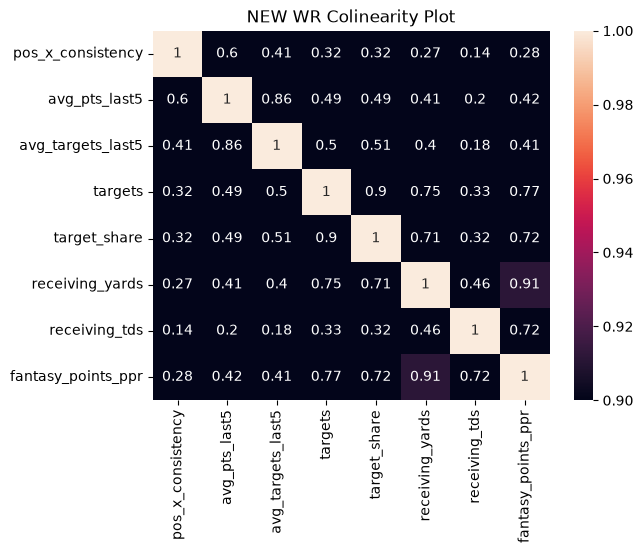

c:\python\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:381: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)


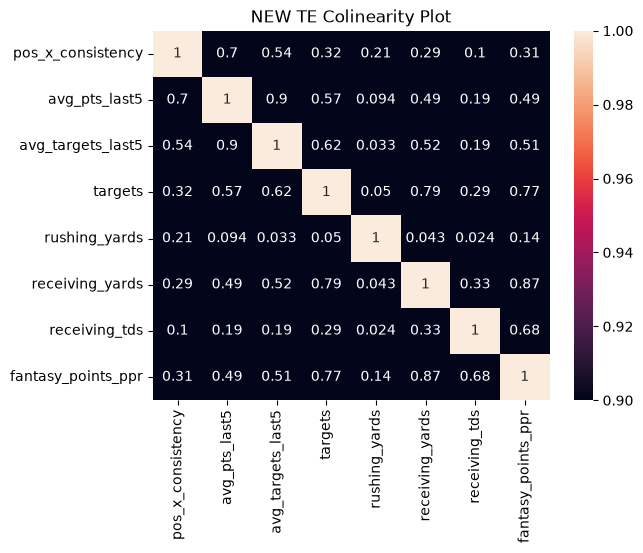

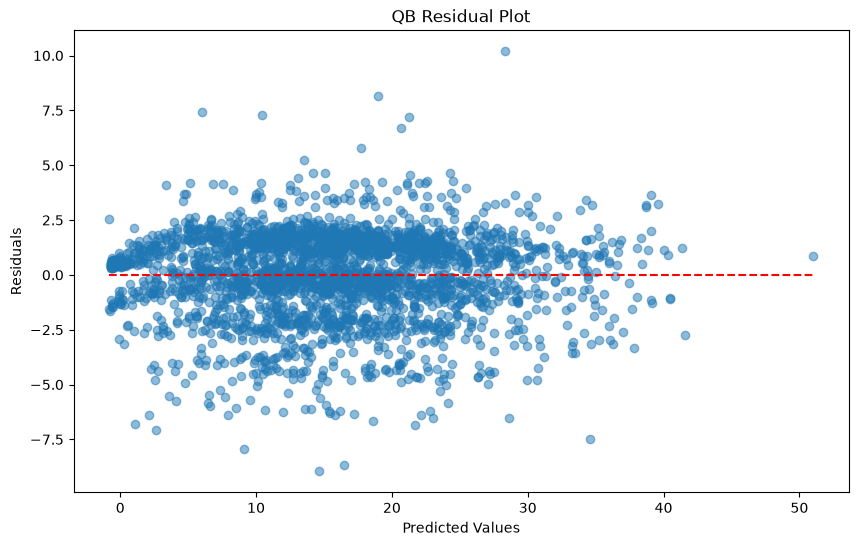

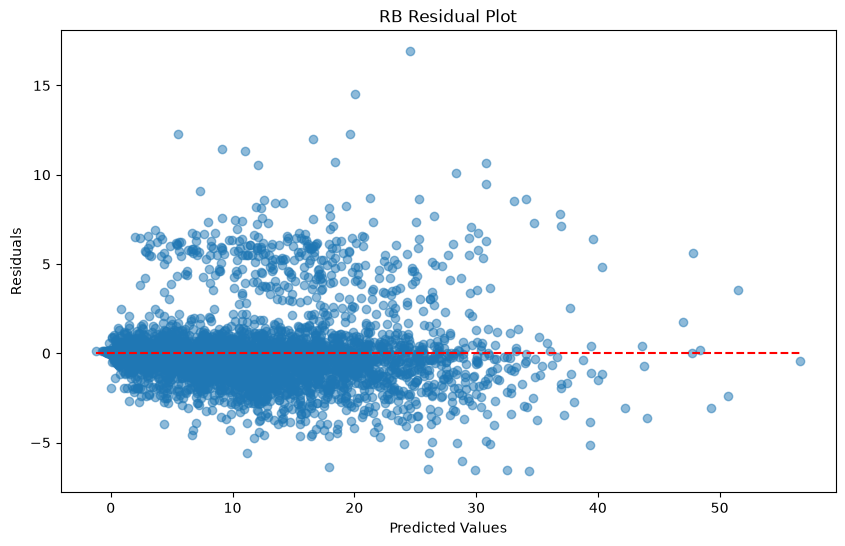

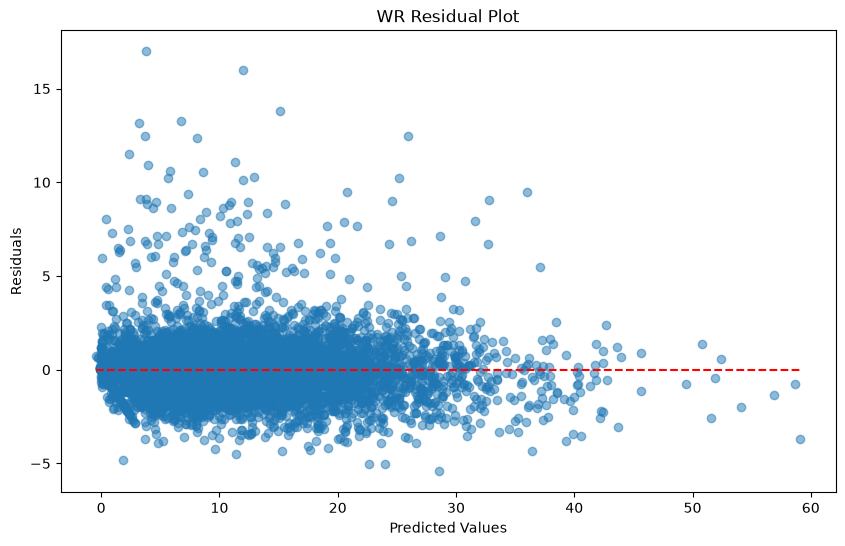

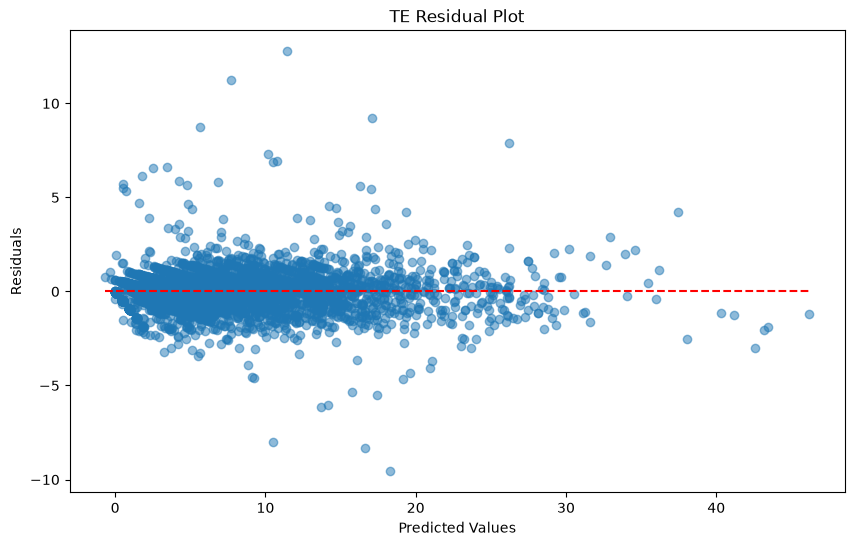


##### KNN MODEL FOR QB #####
Train score: 0.9440
Test score:  0.9118
MAE:  2.0372
MSE:  6.5753
R2:   0.9118

##### XGBOOST MODEL FOR QB #####
Train: 0.9477
Test:  0.9344
MAE:  1.7154
MSE:  4.8886
R2:   0.9344

##### CLUSTER MODEL FOR QB #####
Train: 0.0246
Test:  0.0171


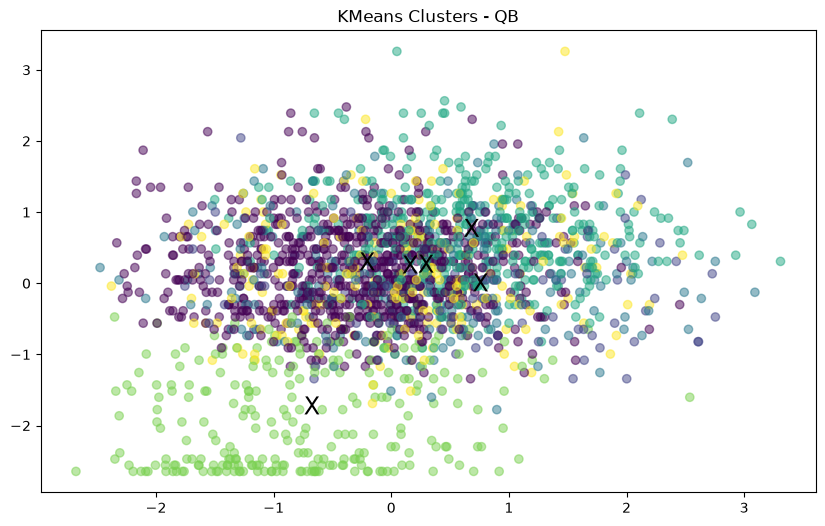

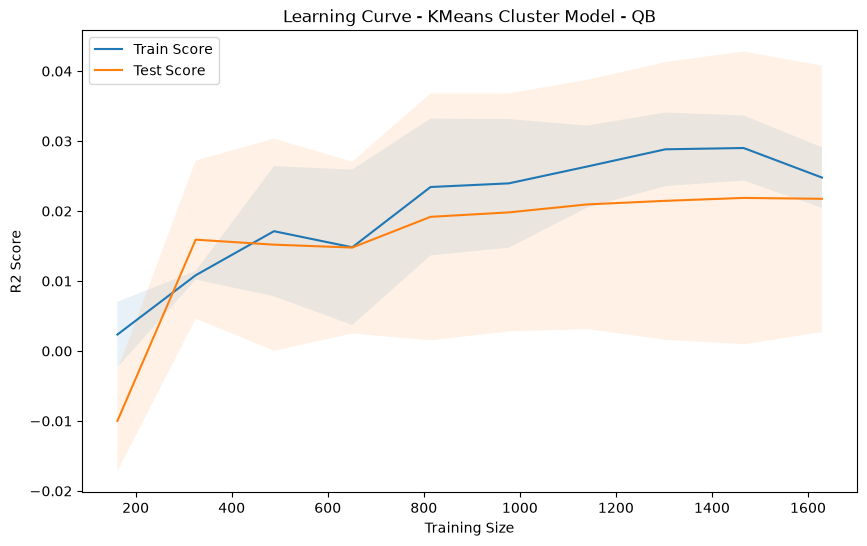


##### KNN MODEL FOR RB #####
Train score: 0.9524
Test score:  0.9244
MAE:  1.3771
MSE:  5.3160
R2:   0.9244

##### XGBOOST MODEL FOR RB #####
Train: 0.9544
Test:  0.9405
MAE:  1.1480
MSE:  4.1806
R2:   0.9405

##### CLUSTER MODEL FOR RB #####
Train: 0.0064
Test:  -0.0011


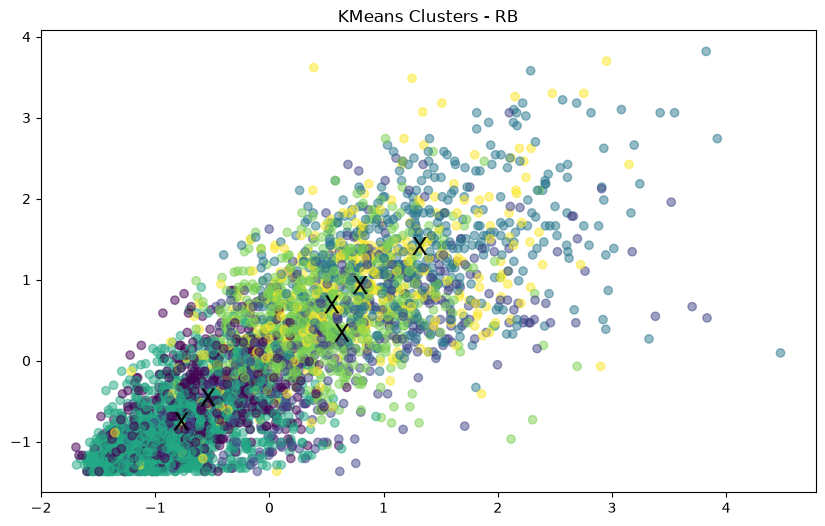

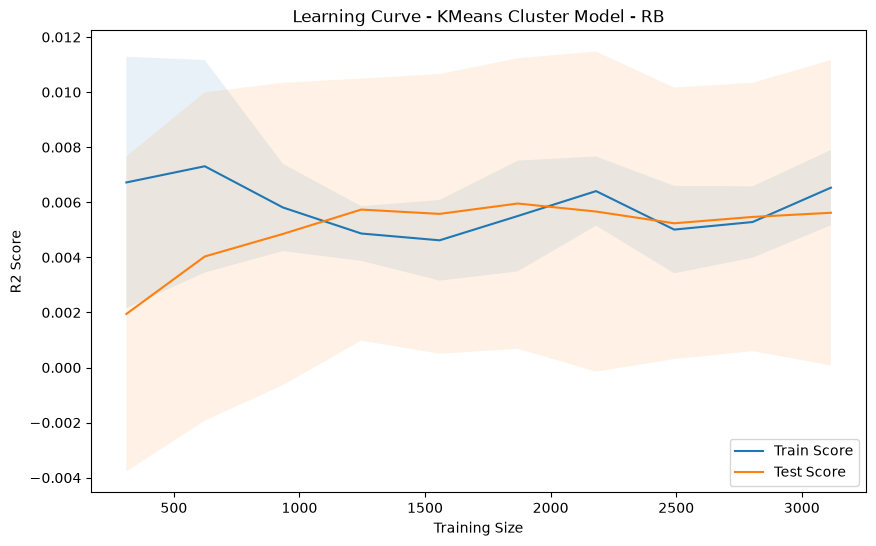


##### KNN MODEL FOR WR #####
Train score: 0.9690
Test score:  0.9485
MAE:  1.2194
MSE:  3.3050
R2:   0.9485

##### XGBOOST MODEL FOR WR #####
Train: 0.9701
Test:  0.9634
MAE:  0.9559
MSE:  2.3483
R2:   0.9634

##### CLUSTER MODEL FOR WR #####
Train: 0.2308
Test:  0.2197


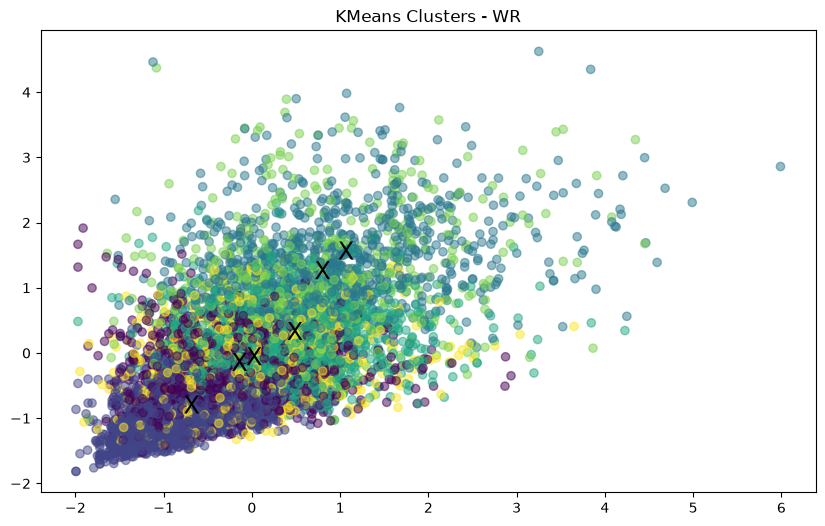

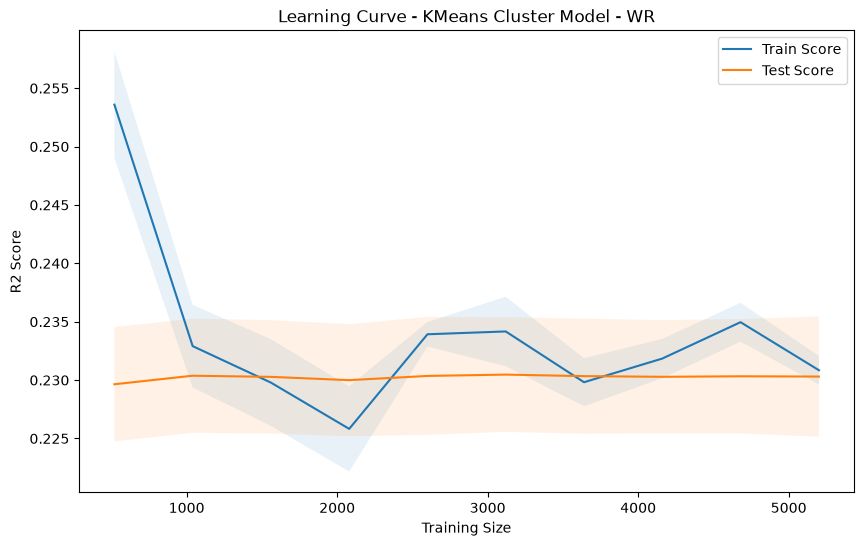


##### KNN MODEL FOR TE #####
Train score: 0.9709
Test score:  0.9592
MAE:  0.7852
MSE:  1.7880
R2:   0.9592

##### XGBOOST MODEL FOR TE #####
Train: 0.9711
Test:  0.9604
MAE:  0.6900
MSE:  1.7383
R2:   0.9604

##### CLUSTER MODEL FOR TE #####
Train: 0.0604
Test:  0.0318


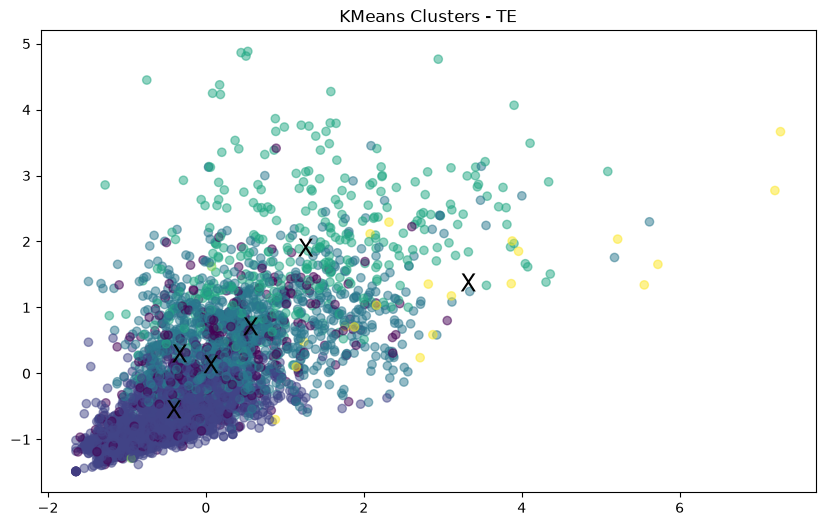

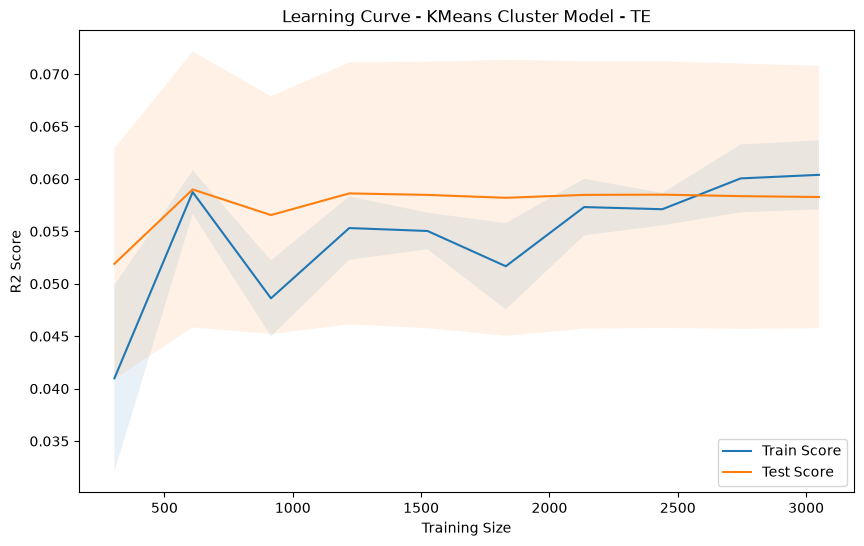

In [ ]:
# %pip install nflreadpy
# %pip install pyarrow

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nflreadpy as nfl
from IPython.display import display

# for data relevancy (and size) only select most recent 3 seasons
seasons = [2020, 2021, 2022, 2023, 2024]
# collect player stats/data
df = nfl.load_player_stats(seasons=seasons).to_pandas()
# address NaNs
df = df.dropna(subset=['player_name'])
print(df.info())

##### EDA
df['fantasy_points_ppr'].plot(kind='hist', title="Output Distribution")
plt.show()

##### VIZ EACH POS
pos = ['QB', 'RB', 'WR', 'TE']
fig, ax = plt.subplots(figsize=(12, 6))
for p in pos:
    df[df['position'] == p]['fantasy_points_ppr'].plot(
        kind='hist', ax=ax, bins=30, alpha=0.5, label=p
    )
ax.set_title('Fantasy Points PPR Distribution by Position')
ax.set_xlabel('Fantasy Points PPR')
ax.set_ylabel('Count')
ax.legend()
plt.show()

##### PLAYER ROLLING AVERAGES
# sort for rolling calcs
df = df.sort_values(['player_name', 'season', 'week']).reset_index(drop=True)
# rolling 5 across season boundaries
df['avg_pts_last5'] = df.groupby('player_name')['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_attempts_last5'] = df.groupby('player_name')['attempts'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_carries_last5'] = df.groupby('player_name')['carries'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_targets_last5'] = df.groupby('player_name')['targets'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_target_share_last5'] = df.groupby('player_name')['target_share'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['avg_rec_yards_last5'] = df.groupby('player_name')['receiving_yards'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
# consistency - low std = less volatile
df['consistency_last5'] = df.groupby('player_name')['fantasy_points_ppr'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=2).std()
)

##### CUT DOWN ON 0s in output
# limit to meaningful contributors only
df = df[
    ((df['position'] == 'QB') & (df['avg_attempts_last5'] >= 10)) |
    ((df['position'] == 'RB') & (df['avg_carries_last5'] >= 3)) |
    ((df['position'] == 'WR') & (df['avg_targets_last5'] >= 2)) |
    ((df['position'] == 'TE') & (df['avg_targets_last5'] >= 1))
].copy()

##### CHECK DIST AGAIN
df['fantasy_points_ppr'].plot(kind='hist', title="Output Distribution after cutting 0s")
plt.show()

##### VIZ EACH POS AGAIN
fig, ax = plt.subplots(figsize=(12, 6))
for p in pos:
    df[df['position'] == p]['fantasy_points_ppr'].plot(
        kind='hist', ax=ax, bins=30, alpha=0.5, label=p
    )
ax.set_title('Fantasy Points PPR Distribution by Position')
ax.set_xlabel('Fantasy Points PPR')
ax.set_ylabel('Count')
ax.legend()
plt.show()

# DEF PTS ALLOWED LAST 5
def_stats = df.groupby(['opponent_team', 'position', 'season', 'week'])['fantasy_points_ppr'].sum().reset_index()
def_stats.columns = ['team', 'position', 'season', 'week', 'pts']
def_stats = def_stats.sort_values(['team', 'position', 'season', 'week'])
def_stats['def_pts_allowed_last5'] = def_stats.groupby(['team', 'position'])['pts'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# merge back - left on opponent_team, right on team
df = df.merge(def_stats[['team', 'position', 'season', 'week', 'def_pts_allowed_last5']],
              left_on=['opponent_team', 'position', 'season', 'week'],
              right_on=['team', 'position', 'season', 'week'],
              how='left').drop(columns=['team_y']).rename(columns={'team_x': 'team'})

##### ENCODE POSITIONS (WEIGHTED MEANS)
pos_avg = df.groupby('position')['fantasy_points_ppr'].mean()
df['pos_enc'] = df['position'].map(pos_avg)

df['pos_x_consistency'] = df['pos_enc'] * df['consistency_last5']
df['pos_x_attempts'] = df['pos_enc'] * df['avg_attempts_last5']
df['pos_x_carries'] = df['pos_enc'] * df['avg_carries_last5']
df['pos_x_targets'] = df['pos_enc'] * df['avg_targets_last5']
df['pos_x_target_share'] = df['pos_enc'] * df['avg_target_share_last5']
df['pos_x_rec_yards'] = df['pos_enc'] * df['avg_rec_yards_last5']

##### MODEL BUILDING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import learning_curve

features = ['pos_enc', 'pos_x_consistency', 'pos_x_attempts', 'pos_x_carries', 'pos_x_targets', 'pos_x_target_share', 'def_pts_allowed_last5',
                  'avg_pts_last5', 'avg_attempts_last5', 'avg_carries_last5', 'avg_targets_last5', 'avg_target_share_last5',
                  'attempts', 'carries', 'targets', 'target_share',
                  'passing_yards', 'passing_tds', 'rushing_yards', 'rushing_tds', 'receiving_yards', 'receiving_tds']

### SPLIT BY POSITION
qb_df = df[df['position'] == 'QB'][features + ['fantasy_points_ppr']].dropna().copy()
rb_df = df[df['position'] == 'RB'][features + ['fantasy_points_ppr']].dropna().copy()
wr_df = df[df['position'] == 'WR'][features + ['fantasy_points_ppr']].dropna().copy()
te_df = df[df['position'] == 'TE'][features + ['fantasy_points_ppr']].dropna().copy()

##### SELECTK not the cereal # select top 7 each pos
pos_dfs = {'QB': qb_df, 'RB': rb_df, 'WR': wr_df, 'TE': te_df }
kselect = SelectKBest(score_func=f_regression, k=7)
for pos, pos_df in pos_dfs.items():
    X = pos_df[features]
    y = pos_df['fantasy_points_ppr']
    X_best = kselect.fit_transform(X, y)
    selected = X.columns[kselect.get_support()].tolist()
    # print(f'{pos} selected features: {selected}')
    
    # rebuild df with selected features + output
    pos_dfs[pos] = pd.DataFrame(X_best, columns=selected)
    pos_dfs[pos]['fantasy_points_ppr'] = y.values

    # col model
    corr = pos_dfs[pos].corr(numeric_only=True).abs()
    sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
    plt.title(pos + " Colinearity Plot")
    plt.show()

##### EXTRA TUNING (DROP COLINEARS)
# none in QB :thumbsup:
# RB => drop targets and reselect
X = rb_df[features].drop(columns='targets')
y = rb_df['fantasy_points_ppr']
kselect = SelectKBest(score_func=f_regression, k=7)
X_best = kselect.fit_transform(X, y)
selected = X.columns[kselect.get_support()].tolist()
pos_dfs['RB'] = pd.DataFrame(X_best, columns=selected)
pos_dfs['RB']['fantasy_points_ppr'] = y.values

# recheck
corr = pos_dfs['RB'].corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.title('NEW RB Colinearity Plot')
plt.show()
# good to go

# WR => drop pos_x_targets and reselect
# after recheck: pos_x_target_share, avg_target_share_last5
X = wr_df[features].drop(columns=['pos_x_target_share', 'avg_target_share_last5', 'pos_x_targets'])
y = wr_df['fantasy_points_ppr']
kselect = SelectKBest(score_func=f_regression, k=7)
X_best = kselect.fit_transform(X, y)
selected = X.columns[kselect.get_support()].tolist()
pos_dfs['WR'] = pd.DataFrame(X_best, columns=selected)
pos_dfs['WR']['fantasy_points_ppr'] = y.values

# recheck
corr = pos_dfs['WR'].corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.title('NEW WR Colinearity Plot')
plt.show()
# good to go

# TE => drop pos_x_targets, avg_target_share_last5 and reselect
# after recheck: target_share, pos_x_target_share
X = te_df[features].drop(columns=['pos_x_targets', 'avg_target_share_last5', 'target_share', 'pos_x_target_share'])
y = te_df['fantasy_points_ppr']
kselect = SelectKBest(score_func=f_regression, k=7)
X_best = kselect.fit_transform(X, y)
selected = X.columns[kselect.get_support()].tolist()
pos_dfs['TE'] = pd.DataFrame(X_best, columns=selected)
pos_dfs['TE']['fantasy_points_ppr'] = y.values

# recheck
corr = pos_dfs['TE'].corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.title('NEW TE Colinearity Plot')
plt.show()
# good to go

##### FEATURES SELECTED
##### NOW THE FUN BEGINS!!!!!
# check residual plots
regr = LinearRegression()
for pos, pos_df in pos_dfs.items():
    X = pos_df.drop(columns='fantasy_points_ppr')
    y = pos_df['fantasy_points_ppr']
    
    regr.fit(X, y)
    preds = regr.predict(X)
    
    plt.figure(figsize=(10, 6))
    plt.title(pos + ' Residual Plot')
    plt.scatter(preds, y - preds, alpha=0.5)
    plt.hlines(y=0, xmin=preds.min(), xmax=preds.max(), color='r', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()
# good to go

##### MODELS
model_knn = KNeighborsRegressor()
scaler = StandardScaler()
model_kmeans_ridge = Ridge()
model_kmeans = KMeans(n_clusters=6, random_state=51)
model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=15,
    random_state=42
)

for pos, pos_df in pos_dfs.items():
    X = pos_df.drop(columns='fantasy_points_ppr')
    y = pos_df['fantasy_points_ppr']
    # train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=51)

    ##### SCALE IT UP
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ##### MODEL #1
    print('\n##### KNN MODEL FOR ' + pos + ' #####')
    model_knn.fit(X_train_scaled, y_train)
    print(f'Train score: {model_knn.score(X_train_scaled, y_train):.4f}')
    print(f'Test score:  {model_knn.score(X_test_scaled, y_test):.4f}')
    y_pred = model_knn.predict(X_test_scaled)  # fixed - was X_test
    print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
    print(f'MSE:  {mean_squared_error(y_test, y_pred):.4f}')
    print(f'R2:   {r2_score(y_test, y_pred):.4f}')

    ##### MODEL #2
    print('\n##### XGBOOST MODEL FOR ' + pos + ' #####')
    model_xgb.fit(X_train, y_train)
    print(f'Train: {model_xgb.score(X_train, y_train):.4f}')
    print(f'Test:  {model_xgb.score(X_test, y_test):.4f}')
    y_pred = model_xgb.predict(X_test)
    print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
    print(f'MSE:  {mean_squared_error(y_test, y_pred):.4f}')
    print(f'R2:   {r2_score(y_test, y_pred):.4f}')

    ##### MODEL #3
    print('\n##### CLUSTER MODEL FOR ' + pos + ' #####')
    
    # fit kmeans and get cluster labels
    model_kmeans.fit(X_train_scaled)
    X_train_clusters = model_kmeans.predict(X_train_scaled).reshape(-1, 1)
    X_test_clusters = model_kmeans.predict(X_test_scaled).reshape(-1, 1)
    
    # fit ridge on cluster labels
    model_kmeans_ridge.fit(X_train_clusters, y_train)
    print(f'Train: {model_kmeans_ridge.score(X_train_clusters, y_train):.4f}')
    print(f'Test:  {model_kmeans_ridge.score(X_test_clusters, y_test):.4f}')

    # cluster scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
                c=model_kmeans.labels_, alpha=0.5)
    for center in model_kmeans.cluster_centers_:
        plt.text(s='X', x=center[0], y=center[1], color='k', size='xx-large')
    plt.title(f'KMeans Clusters - {pos}')
    plt.show()

    # learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        model_kmeans_ridge, X_train_clusters, y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(train_sizes, train_scores.mean(axis=1), label='Train Score')
    ax.plot(train_sizes, test_scores.mean(axis=1), label='Test Score')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    ax.fill_between(train_sizes,
                    test_scores.mean(axis=1) - test_scores.std(axis=1),
                    test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.1)
    ax.set_title(f'Learning Curve - KMeans Cluster Model - {pos}')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('R2 Score')
    ax.legend()
    plt.show()


# Can fantasy football points be predicted by pregame metrics?

## Why fantasy football?
I was born and raised in the Philadelphia area and this area has a huge tie to their sports teams. From a young age, I took a big interest. I have been playing fantasy football since I was 16. I have always really enjoyed getting lost in the statistics of fantasy football, and really anything else down to electric usage in my home. I took this project as an opprotunity to test some of my mad scientist theories about fantasy football predictions. These include:
- Weather matters. Cold and wind specifically.
- If a team is ranked within the top or bottom 5 in pts allowed, the defensive matchup would play a part.
- Injuries keep a lot of players from playing at their full potential.

**I finally have the answers!!!** I am confident that I have disproved ALL of these theories through methods we learned in class.

## Schedule Data (Weather, Setting, Home/Away)

```
# need more contextual data about the game
# load schedules data which has game conditions
sched = nfl.load_schedules().to_pandas()
sched = sched[['game_id', 'home_team', 'away_team', 'roof', 'surface', 'temp', 'wind']]

# merge using game_id since we already have it
df = df.merge(sched, on='game_id', how='left')

df['is_home'] = (df['team'].values == df['home_team']).astype(int)
df['is_dome'] = df['roof'].isin(['dome', 'closed']).astype(int)
df['is_grass'] = (df['surface'] == 'grass').astype(int)

# address NaNs
df.loc[df['roof'].isin(['dome', 'closed']), 'temp'] = df['temp'].fillna(70)
df.loc[df['roof'].isin(['dome', 'closed', 'open']), 'wind'] = df['wind'].fillna(0)
```

After visualizing this data with our output, the correlation plot didn't show favorable values. Instead of many values in the roof and surface features, I thought that simplifying the variable might help by creating is_dome and is_grass. Grass is widely known as the player favorite to play on and the dome offers football unimpeded by the elements, however these values changed slightly, they were still too small to include. Before removing the data entirely, I dedcided to try out the fantasy football home field advantage, which turned out to be nearly non-existent. After confirming that the data here would not be useful to training a model, I removed the data and moved on.

## Injury Data
```
inj = nfl.load_injuries(seasons=seasons).to_pandas()

# injury impact mapping
high_impact = ['Knee', 'Ankle', 'Hamstring', 'Foot', 'Hip', 'Quad', 'Calf', 'Thigh', 'Achilles', 'Concussion', 'Head', 'Ribs', 'Back', 'Neck']
low_impact  = ['Shoulder', 'Elbow', 'Wrist', 'Hand', 'Thumb', 'Finger', 'Chest', 'Bicep', 'Tricep']
# helper func to encode inj impact
def get_inj_impact(injury):
    if pd.isna(injury):
        return 0
    injury = str(injury)
    if any(body_part in injury for body_part in high_impact):
        return 2
    elif any(body_part in injury for body_part in low_impact):
        return 1
    return 0

# encode prac and report inj impact
inj['inj_report_impact'] = inj['report_primary_injury'].apply(get_inj_impact)
inj['inj_prac_impact'] = inj['practice_primary_injury'].apply(get_inj_impact)

# encode report status
status_map = {
    'Out': 0,
    'Doubtful': 1,
    'Questionable': 2
}
inj['report_status_enc'] = inj['report_status'].map(status_map).fillna(3)

# encode practice status
practice_map = {
    'Did Not Participate In Practice': 0,
    'Limited Participation in Practice': 1,
    'Full Participation in Practice': 2
}
inj['practice_status_enc'] = inj['practice_status'].map(practice_map).fillna(2)

# cut to what we need
inj = inj[['gsis_id', 'full_name', 'team', 'season', 'week', 
                      'report_status_enc', 'practice_status_enc',
                      'inj_report_impact', 'inj_prac_impact']]

# merge inj with df
df = df.merge(inj[['gsis_id', 'season', 'week', 'report_status_enc', 'practice_status_enc', 'inj_report_impact', 'inj_prac_impact']], 
              left_on=['player_id', 'season', 'week'],
              right_on=['gsis_id', 'season', 'week'],
              how='left')

# players not in injury report are healthy
df['report_status_enc'] = df['report_status_enc'].fillna(3)
df['practice_status_enc'] = df['practice_status_enc'].fillna(2)
df['inj_report_impact'] = df['inj_report_impact'].fillna(0)
df['inj_prac_impact'] = df['inj_prac_impact'].fillna(0)
```

A huge indicator of a players performance is their health, however after exploring this data, I found that there was only 2000/54000 rows that merged. After some research, I learned that if the player is Out, there is no row in the fantasy player stats table. The corr value (0.04ish) for these injury features were actually pretty strong considering there was only 2000 values. I was hoping that this would reduce the amount of 0s in the dataset by explaining them with this data addition. However, that wasn't the case and since the data only explained 4% of the data, it wasn't worth keeping.

## Defensive Ranks Weighted

```
### WEIGHTED EXPERIMENT
#  --- TEST 1: rank 1 - 32
def_stats['def_rank'] = def_stats.groupby(['position', 'season', 'week'])['def_pts_allowed_last5'].rank(ascending=False)

# --- TEST 2: binary tiers (-2, 0, 2) ---
def_stats['def_tier_binary'] = 0
def_stats.loc[def_stats['def_rank'] <= 7, 'def_tier_binary'] = -2   # tough matchup
def_stats.loc[def_stats['def_rank'] >= 26, 'def_tier_binary'] = 2   # easy matchup

# --- TEST 3: scaled tiers (1-7) ---
def_stats['def_rank_w'] = 0
# rank 1 = easiest (most pts allowed) = positive 7
def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank_w'] = \
    (8 - def_stats.loc[def_stats['def_rank'] <= 7, 'def_rank'])
# rank 32 = toughest (fewest pts allowed) = negative 7
def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank_w'] = \
    (25 - def_stats.loc[def_stats['def_rank'] >= 26, 'def_rank'])
```

### Output
- fantasy_points_ppr       1.000000
- def_rank_w               0.105071
- def_pts_allowed_last5    0.102807
- def_rank                -0.030399
- def_tier_binary         -0.096029

In my own experience, when a player faces a tough defense they score less points, and vice versa. Usually, this only really applies to the elite top/bottom 5 or so defenses. With this experiment, I was able to run a series of tests to prove that hypothesis. I wanted to compare these three methods against each other. In the output, you can see that the ranked weights worked the best out of these methods by limiting the noise of the inner 18 teams. Once these features were added to the positions, they become much weaker in correlation. I'm exploring other ways to weight or manipulate these values to see if the signal will increase.

## Matchup Difference Bell Curve
I didn't feel like defense gave enough context to the data, since there is no way to tell between a BAD v BAD matchup and a GOOD v BAD matchup. Using the same method outlined above, I calculated offensive team points scored, then calculated a matchup difference. When viewing the distribution of this feature, I noticed a bell curve and wanted to test it against a polynomial model. The poly helped greatly and put the r2 score around 0.3. However, when a decision was made to cut 0s and split into positions, the values dropped under 0.1. See splitting by positions and cutting 0s sections for more.

```
##### MATCHUP DIFFERENTIAL
df['matchup_diff'] = df['off_pts_last5'] - df['def_pts_allowed_last5']
# df['matchup_diff'].plot(kind='hist')
# plt.show()

# histogram is clearly poly - change feature to poly
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
match_poly = poly.fit_transform(df[['matchup_diff']].fillna(0))
df['matchup_diff_poly'] = match_poly[:, 0]
df['matchup_diff_sq'] = match_poly[:, 1]
```

## Splitting by Position
```
### SPLIT BY POSITION
qb_df = df[df['position'] == 'QB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_attempts_last5', 'avg_carries_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

rb_df = df[df['position'] == 'RB'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_carries_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

wr_df = df[df['position'] == 'WR'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()

te_df = df[df['position'] == 'TE'][[
    # 'player_name', 'team', 'season', 'week', 'season_type', 'opponent_team',
    'avg_pts_last5', 'avg_targets_last5', 'avg_target_share_last5',
    'off_pts_last5', 'def_pts_allowed_last5', 'matchup_diff_sq', 'matchup_diff_poly',
    'fantasy_points_ppr'
]].copy()
```

Surprisingly, nearly every feature does worse when the dataframe split by position. There are a few features that apply, mostly, to one position, so I thought this might be a good idea. Since the team stats are done in a way that allows the split by position, I thought with the more focused statistic that they would be more correlated. After experimentation, the loss of the large data pool that told a bigger story was the issue. It was more focused data, but MUCH less data. Without this data, the correlation becomes much weaker.

## Cutting 0s
When I first viewed the data, I thought the oversaturation of 0s was from injuries, but since they weren't I deemed that data as informative for the model. After testing with splitting by position, it became more clear that all the 0s was an overclassification issue. Was the model guessing the score right or just guessing whether the player was a starter or a backup? Identifying this and removing the 0s changed the model completely and nerfed many of the features I was engineering. This meant it was time for a reapproach.

## Mean-weighted Positions
After talking about clusters in class, I thought that trying to create clusters might be a good idea. To do this, I found the mean points for each position, then used that to multiply against strong features to see if the model could discern the data between the positions. This worked well until cutting 0s and splitting by position, which you can see in the script above. The cluster analysis didn't exceed 0.3 r2, as with most of my engineered features.

# Choosing a Model for each Position
The KNN model closely competed with all models except QB. The distribution of QB scores without 0s suggests a bell curve, and maybe a polynomial model woould have worked well here. If I had a choice for the data all together, I would continue with the cluster idea around mean-weighted features as that seemed to work very well in my limited testing.
- **QB**: XGBOOST
- **RB**: XGBOOST
- **WR**: XGBOOST
- **TE**: XGBOOST

I hope you enjoyed and thanks for reading!